In [1]:
%load_ext autoreload
%autoreload 2
from finsler_embedding.experiment_run import *
from geodesic_toolbox.cometric import CentroidsCometric, IdentityCoMetric
from geodesic_toolbox.utils import get_mf_image
from sklearn.manifold import Isomap, SpectralEmbedding


/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
def get_spiral(n_pts: int, freq: float, sigma: float = 0.1, t_max: float = 4 * np.pi,device: str = "cpu") -> tuple[torch.Tensor, torch.Tensor]:
    # Sample uniformly in arc length on the noiseless spiral, then add noise.
    t_dense = np.linspace(0.0, t_max, max(5000, 10 * n_pts))
    speed = np.sqrt(1.0 + (freq * t_dense) ** 2)
    ds = 0.5 * (speed[1:] + speed[:-1]) * np.diff(t_dense)
    s_dense = np.concatenate(([0.0], np.cumsum(ds)))
    s_uniform = np.linspace(0.0, s_dense[-1], n_pts)
    t = np.interp(s_uniform, s_dense, t_dense)

    x = t * np.cos(freq * t) + np.random.normal(0, sigma, n_pts)
    y = t * np.sin(freq * t) + np.random.normal(0, sigma, n_pts)
    X = np.stack([x, y], axis=1)

    # Normalize the data
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    s = s_uniform / s_uniform[-1]
    X = torch.from_numpy(X).double().to(device)
    s = torch.from_numpy(s).double().to(device)
    return X, s

def spiral_omega(z: torch.Tensor, freq: float) -> torch.Tensor:
    """
    Compute the omega vector field for a spiral.

    Parameters:
    ----------
    z : torch.Tensor (n_points, 2)
        The input points in 2D space.
    freq : float
        The frequency of the spiral.

    Returns:
    -------
    torch.Tensor (n_points, 2)
        The omega vector field at the input points.
    """
    x = z[:, 0]
    y = z[:, 1]
    t = torch.sqrt(x**2 + y**2)
    omega_x = -freq * y / (t + 1e-8)  # Avoid division by zero
    omega_y = freq * x / (t + 1e-8)   # Avoid division by zero
    omega = torch.stack([omega_x, omega_y], dim=1)
    return omega / torch.norm(omega, dim=1, keepdim=True)  # Normalize the vector field

class OmegaSpiral(torch.nn.Module):
    def __init__(self, cometric:CoMetric, freq: float = 1.0):
        super().__init__()
        self.cometric = cometric
        self.freq = freq

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        omega = spiral_omega(z, freq=self.freq)
        norm_omega = self.cometric.cometric(z, omega)
        omega = omega / (norm_omega.unsqueeze(1) + 1e-8)  # Avoid division by zero
        return omega

In [3]:
cfg = ExperimentConfig(
    N=5000,
    m=2,
    beta=0.9,
    K=400,
    n_neighbors=10,
    omega_type="random", # Not used here
    function_type="mexican",
    # function_type="coordinates",
    device="cpu",
    export_path=None,
)

In [4]:
X,t = get_spiral(cfg.N, freq=1.0, sigma=0.2, t_max=4 * np.pi, device=cfg.device)
# Shuffle the data to avoid any ordering effects
idx = torch.randperm(X.shape[0])
X = X[idx]
t = t[idx]
cfg.N = X.shape[0]  # Update N in case of grid sampling
X = X.to(torch.float).to(cfg.device)
bounds = get_bounds(X, margin=0.1)

base_cometric = IdentityCoMetric().to(cfg.device)
base_cometric = CentroidsCometric(centroids=X, cometric_centroids=base_cometric(X))
omega_true = OmegaSpiral(cometric=base_cometric, freq=1.0).to(cfg.device)
randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=cfg.beta,
)
mf = get_mf_image(base_cometric, X,bounds=bounds)


Computing magnification factor: 100%|██████████| 79/79 [00:00<00:00, 91.83batch/s]


In [5]:
b_true = randers_metric.omega(X) * randers_metric.beta
v_true = b_to_v(b_true, base_cometric.cometric_tensor(X)).detach()
v_true_norm = v_true.norm(dim=1)

In [6]:
edges = get_knn_graph(X, n_neighbors=10, device=cfg.device)
LOGGER.info(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X, edges, randers_metric,use_approx=True)


[2026-09-16 17:15:39] - INFO - Found 60938 edges in the KNN graph.


Computing Randers distances: 100%|██████████| 610/610 [00:17<00:00, 34.51it/s]


In [7]:
epsilon = compute_epsilon_empirical(dst_edges,scale=10)

W, mu_0, mu_1 = gaussian_kernel(edges, dst_edges, epsilon, cfg.N, cfg.m)
c_km = -mu_1 / mu_0 * (cfg.m + 1) / cfg.m
c_km = 1 / c_km

Q_inv_theta = get_Q_inv_theta(W, theta=1)
W_theta_s, W_theta_a = get_W_thetas(W, Q_inv_theta)
P_theta_s, P_theta_a = construct_P_thetas(W_theta_s, W_theta_a)
L_theta_s = 1 / epsilon**2 * P_theta_s
L_theta_a = 1 / epsilon * P_theta_a

In [8]:
# eigenvalues, eigenvectors = torch.linalg.eigh(L_theta_s)
# K = 2
# X_low = eigenvectors[:, :K] * eigenvalues[:K]

X_low = SpectralEmbedding(n_components=2, affinity='precomputed').fit_transform(W_theta_s.detach().cpu().numpy())
X_low = torch.from_numpy(X_low).float().to(cfg.device)


base_cometric_low = CentroidsCometric(centroids=X_low, cometric_centroids=IdentityCoMetric().to(cfg.device)(X_low))
# base_cometric_low = IdentityCoMetric().to(cfg.device)

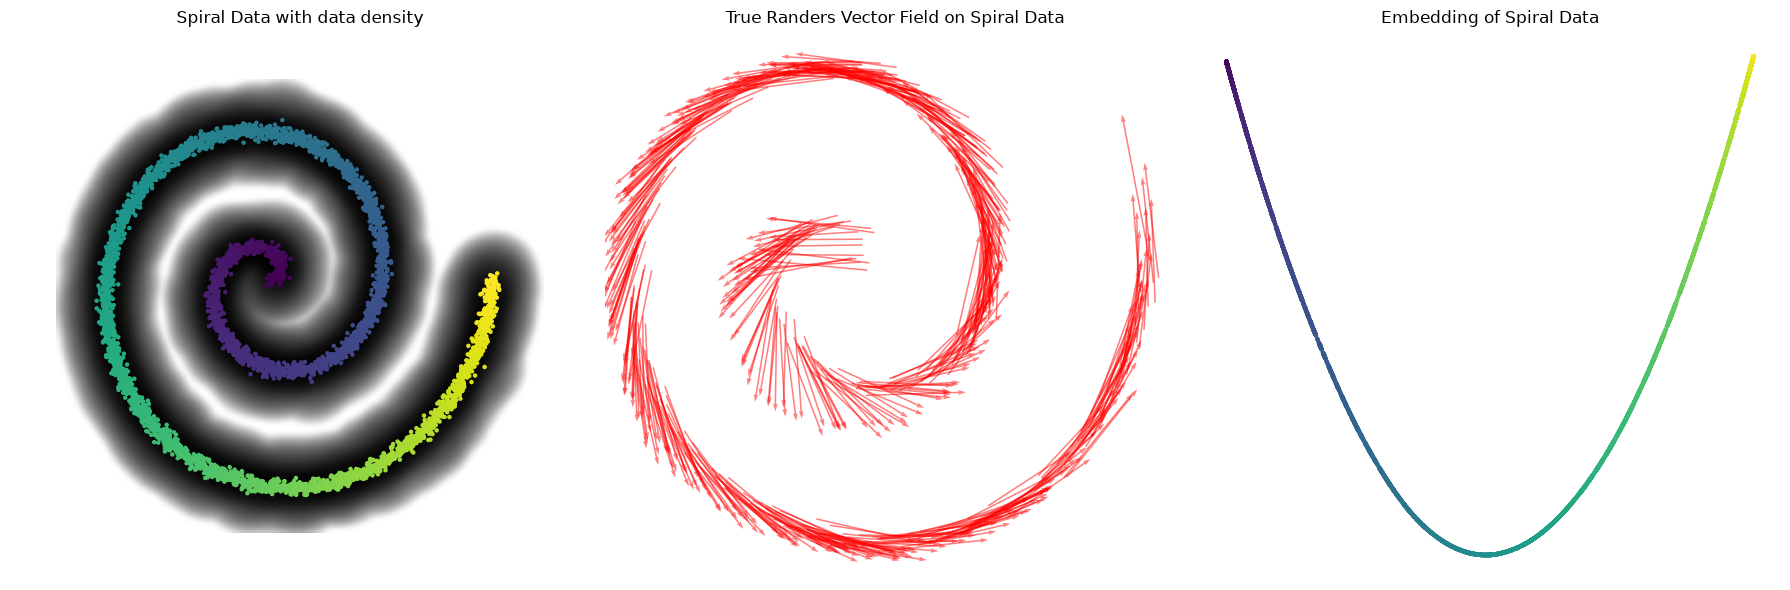

In [9]:
skip = 10  # Skip every 10th point for quiver plot to reduce clutter


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(mf.cpu().numpy(), extent=bounds, origin="lower", cmap="gray")
axes[0].scatter(X[:, 0].detach().cpu(), X[:, 1].detach().cpu(), c=t.cpu(), cmap="viridis", s=5)
axes[0].set_title("Spiral Data with data density")
axes[1].quiver(
    X[::skip, 0].detach().cpu(),
    X[::skip, 1].detach().cpu(),
    b_true[::skip, 0].detach().cpu(),
    b_true[::skip, 1].detach().cpu(),
    color="red",
    scale=0.5,
    alpha=0.5,
)
axes[1].set_title("True Randers Vector Field on Spiral Data")
axes[2].scatter(X_low[:, 0].detach().cpu(), X_low[:, 1].detach().cpu(), c=t.cpu(), cmap="viridis", s=5)
axes[2].set_title("Embedding of Spiral Data")
axes[2].axis("off")
for ax in axes[:-1]:
    ax.set_xlim(bounds[0], bounds[1])
    ax.set_ylim(bounds[2], bounds[3])
    ax.axis("equal")
    ax.axis("off")
plt.tight_layout()
plt.show()

# High dim learning

In [10]:
f_values_high, Lf_values_high, f_grad_values_high = prepare_test_functions(
        cfg.K, cfg.function_type, X, L_theta_a
    )

[2026-09-16 17:16:03] - INFO - Training vector field models...


Loss: 1.7313e-02: 100%|██████████| 1000/1000 [00:02<00:00, 491.49it/s]


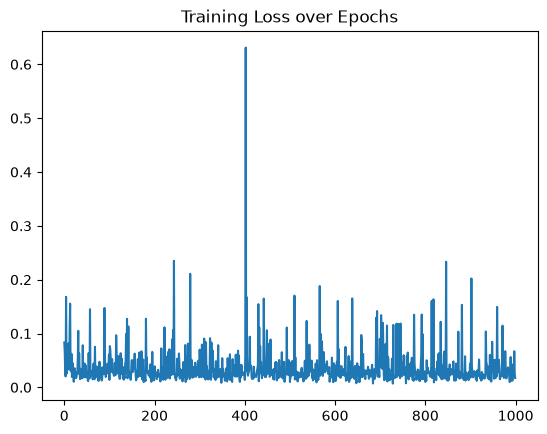

Relative Error (%) Statistics on the prediction of the operator:


{'mean': 214.26730346679688,
 'std': 16477.3671875,
 'min': 0.0,
 'max': 13684444.0,
 'quantile_5': 0.0,
 'quantile_25': 0.0,
 'median': 13.693594932556152,
 'quantile_75': 87.36087036132812,
 'quantile_95': 429.3069152832031}

In [11]:
LOGGER.info("Training vector field models...")
v_model, omega_model, loss_list = train_vector_field_models(
    X, base_cometric, c_km, f_values_high, Lf_values_high, f_grad_values_high
)
v_hat_deep_high = v_model(X).detach()
b_hat_deep_high = omega_model(X).detach()
plt.plot(loss_list)
plt.title("Training Loss over Epochs")
plt.show()

# Compute relative error:
rhs = c_km * torch.einsum('n d, k n d -> k n', v_hat_deep_high, f_grad_values_high)  # (1, N)
relative_error = torch.where(torch.abs(Lf_values_high) > 1e-8, torch.abs(Lf_values_high - rhs) / torch.abs(Lf_values_high) * 100, torch.zeros_like(Lf_values_high))
print(f"Relative Error (%) Statistics on the prediction of the operator:")
qqt_summary_statistics(relative_error.flatten())

In [12]:
b_norm = base_cometric.cometric(X, b_true).detach()
b_deep_high_norm = base_cometric.cometric(X, b_hat_deep_high).detach()
b_norm.mean(), b_deep_high_norm.mean(), b_deep_high_norm.std(), b_deep_high_norm.max()

(tensor(0.9000), tensor(0.0034), tensor(0.0009), tensor(0.0072))

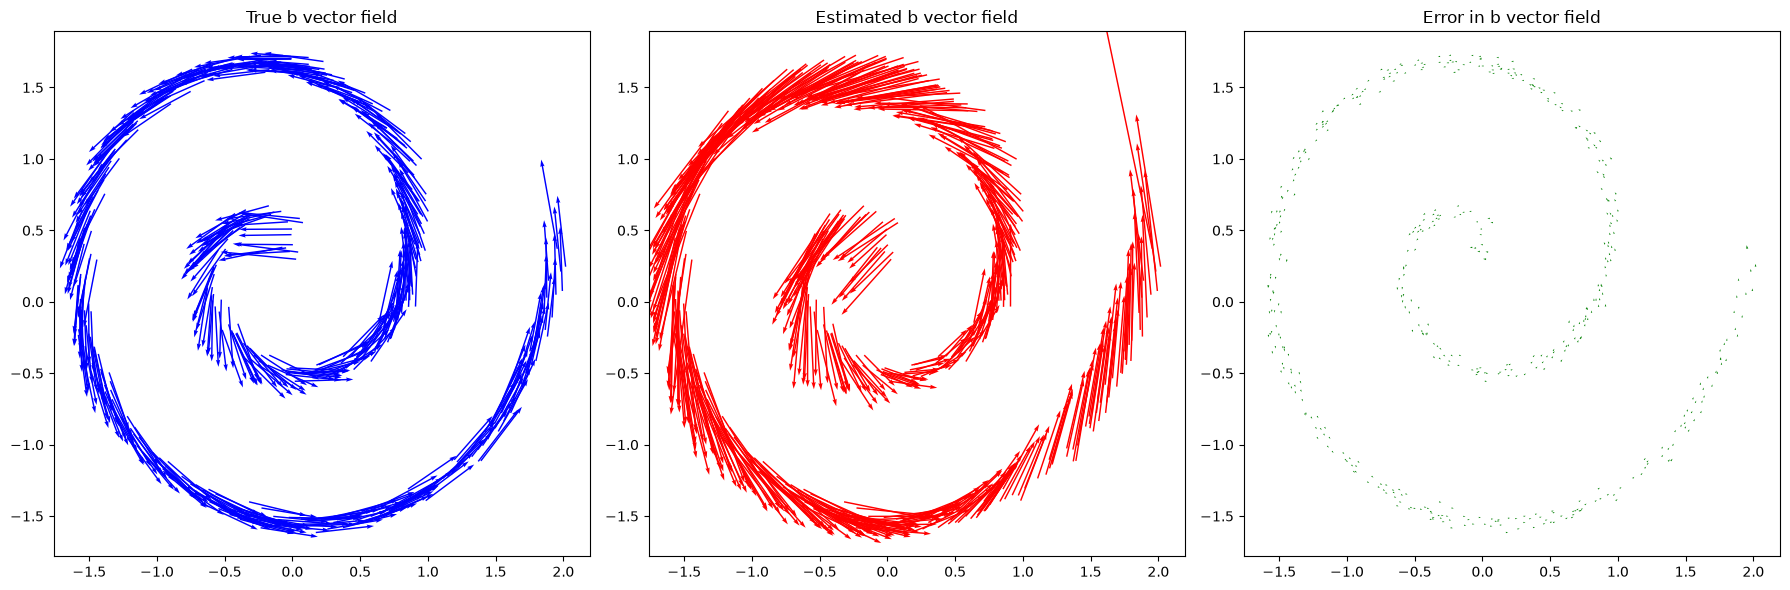

In [13]:
fig, axes = plot_side_by_side(X,b_true, b_hat_deep_high,skip=10, scale_b=.2, scale_bhat=0.0005)

[2026-09-16 17:16:07] - INFO - Cosine similarity between true b and estimated b (Deep Model) should be 1
[2026-09-16 17:16:07] - INFO - Cosine similarity: mean = 9.62e-01, std = 5.17e-02, min = 6.16e-01, max = 1.00e+00
{'mean': 0.9624059796333313, 'std': 0.05165068432688713, 'min': 0.6157385110855103, 'max': 1.0, 'quantile_5': 0.8731755614280701, 'quantile_25': 0.9393640160560608, 'median': 0.9840923547744751, 'quantile_75': 0.9987722039222717, 'quantile_95': 0.9999639987945557}


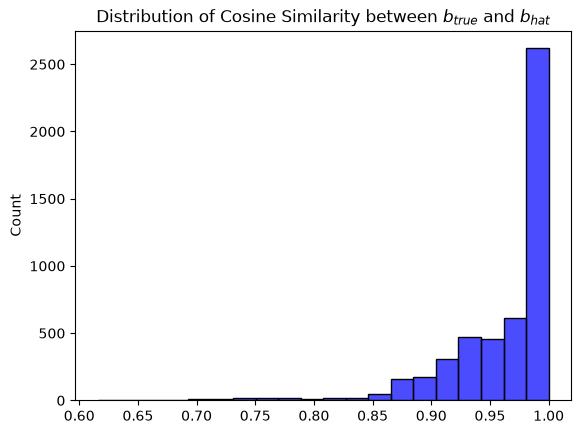

In [14]:
res_cosine_similarity_deep, cosine_similarity_deep = check_cosim_estimate(
        b_hat_deep_high, b_true
    )
print(qqt_summary_statistics(cosine_similarity_deep.flatten()))
sns.histplot(cosine_similarity_deep.flatten().cpu().detach().numpy(), bins=20, color="blue", alpha=0.7)
plt.title(r"Distribution of Cosine Similarity between $b_{true}$ and $b_{hat}$")
plt.vlines(x=1, ymin=0, ymax=axes[0].get_ylim()[1], colors="r", linestyles="dashed", label=r"$\cos(b_{true}, b_{hat}) = 1$")
plt.show()

# Low dim learning

In [15]:
f_values_low, Lf_values_low, f_grad_values_low = prepare_test_functions(
        cfg.K, cfg.function_type, X_low, L_theta_a
    )

[2026-09-16 17:16:08] - INFO - Training vector field models...


Loss: 4.4306e-04: 100%|██████████| 1000/1000 [00:01<00:00, 537.68it/s]


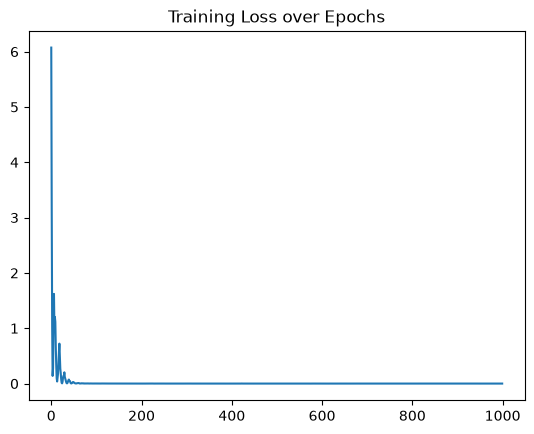

Relative Error (%) Statistics on the prediction of the operator:


{'mean': 555.9730224609375,
 'std': 31764.650390625,
 'min': 0.0,
 'max': 39103996.0,
 'quantile_5': 7.803318500518799,
 'quantile_25': 38.071128845214844,
 'median': 76.42772674560547,
 'quantile_75': 208.7529296875,
 'quantile_95': 1358.9420166015625}

In [16]:
LOGGER.info("Training vector field models...")
v_model, omega_model, loss_list = train_vector_field_models(
    X_low, base_cometric_low, c_km, f_values_low, Lf_values_low, f_grad_values_low
)
v_hat_deep_low = v_model(X_low).detach()
b_hat_deep_low = omega_model(X_low).detach()
plt.plot(loss_list)
plt.title("Training Loss over Epochs")
plt.show()

# Compute relative error:
rhs = c_km * torch.einsum('n d, k n d -> k n', v_hat_deep_low, f_grad_values_low)  # (1, N)
relative_error = torch.where(torch.abs(Lf_values_low) > 1e-8, torch.abs(Lf_values_low - rhs) / torch.abs(Lf_values_low) * 100, torch.zeros_like(Lf_values_low))
print(f"Relative Error (%) Statistics on the prediction of the operator:")
qqt_summary_statistics(relative_error.flatten())

In [17]:
base_cometric_low.cometric(X_low,b_hat_deep_low).max() # Ptdr wtf

tensor(5.3808e-05, grad_fn=<MaxBackward1>)

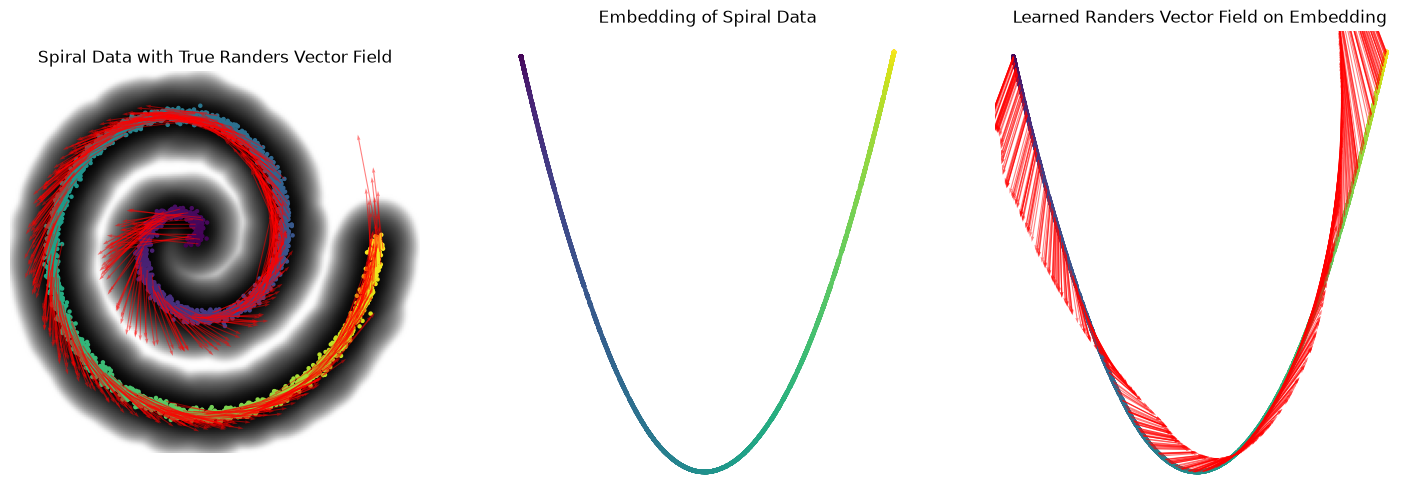

In [18]:
skip=10
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(mf.cpu().numpy(), extent=bounds, origin="lower", cmap="gray")
axes[0].scatter(X[:, 0].detach().cpu(), X[:, 1].detach().cpu(), c=t.cpu(), cmap="viridis", s=5)
axes[0].quiver(
    X[::skip, 0].detach().cpu(),
    X[::skip, 1].detach().cpu(),
    b_true[::skip, 0].detach().cpu(),
    b_true[::skip, 1].detach().cpu(),
    color="red",
    scale=0.5,
    alpha=0.5,
)
axes[0].set_title("Spiral Data with True Randers Vector Field")
axes[0].set_aspect('equal', adjustable='box') 
axes[1].scatter(X_low[:, 0].detach().cpu(), X_low[:, 1].detach().cpu(), c=t.cpu(), cmap="viridis", s=5)
axes[1].set_title("Embedding of Spiral Data")
axes[2].scatter(X_low[:, 0].detach().cpu(), X_low[:, 1].detach().cpu(), c=t.cpu(), cmap="viridis", s=5)
axes[2].quiver(
    X_low[::skip, 0].detach().cpu(),
    X_low[::skip, 1].detach().cpu(),
    b_hat_deep_low[::skip, 0].detach().cpu(),
    b_hat_deep_low[::skip, 1].detach().cpu(),
    color="red",
    scale=0.000008,
    alpha=0.5,
)
axes[2].set_title("Learned Randers Vector Field on Embedding")
# Increase xlim on axes[2] 
# axes[2].set_xlim(-6, 12)
for ax in axes:
    ax.axis("off")   

tensor([2.1209e-06, 3.6250e-07, 5.3882e-07,  ..., 6.9230e-07, 5.1386e-07,
        6.5416e-07], grad_fn=<SqrtBackward0>)

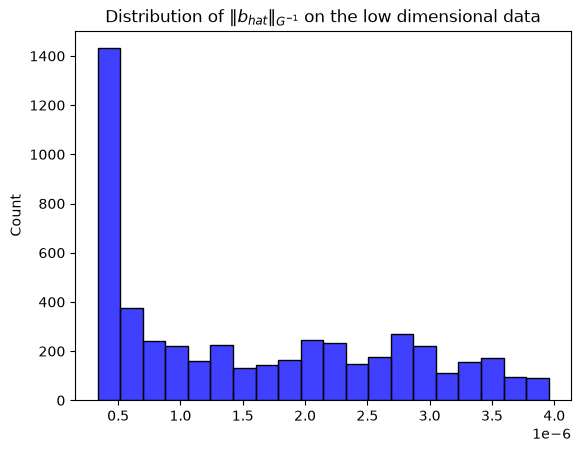

In [19]:
sns.histplot(base_cometric.cometric(X_low,b_hat_deep_low).detach(), bins=20, color="blue")
plt.title(r"Distribution of $\|b_{hat}\|_{G^{-1}}$ on the low dimensional data")
base_cometric.cometric(X_low,b_hat_deep_low)
